# Etapa 7 — Avaliação Cruzada · Stage 3 (Ollama embeddings)

Este notebook reavalia os 4 modelos do projeto (BiLSTM original, BiLSTM reduzido, XGBoost, Transformer) sobre o dataset **1.227 dias × 1.035 features (11 preço + 1.024 embeddings Ollama qwen3-embedding:4b)**, usando os utilitários compartilhados em `shared/` para garantir comparabilidade entre etapas.

## Protocolo

- Split walk-forward 70/15/15 (sem leakage temporal).
- Mesma normalização e mesmo target binário (sobe/desce).
- Métricas reportadas: **ROC-AUC** (primária), F1 por classe, accuracy, matriz de confusão.
- Resultados salvos em `results/` para consolidação cross-stage.

## Hipótese desta configuração

Embeddings genéricos de alta dimensionalidade fornecem sinal suficiente para prever direção de preços. *Resultado esperado: AUC ~ 0.61 (XGBoost), demais modelos próximos do acaso.*

Ver `README.md` desta pasta e `BALANCEAMENTO_DE_CLASSES.md` para discussão de métricas em datasets desbalanceados.

In [1]:
import sys
import os
import logging

sys.path.insert(0, '.')

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")

from shared.data_loader import load_stage3_ollama
from shared.trainer import train_and_evaluate, save_results_json
from shared.plots import (
    plot_roc_curves,
    plot_confusion_matrices,
    plot_calibration_diagrams,
    plot_temporal_stability,
    plot_prediction_distributions,
    plot_learning_curves,
    plot_feature_importance,
    plot_shap_summary,
)

print("Modulos carregados com sucesso")

18:46:15 [INFO] Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
18:46:15 [INFO] NumExpr defaulting to 16 threads.


Modulos carregados com sucesso


# Stage 3: Ollama Embeddings — Avaliacao Completa

Retreino dos 7 modelos com embeddings Ollama (1024 dims -> PCA 32) + preco. Dataset: ~1227 dias, 43 features (11 preco + 32 PCA), horizonte 21 dias.

In [2]:
data = load_stage3_ollama(horizon=21, pca_components=32, window=30)
print(f"Descricao: {data['description']}")
print(f"Sequencias: {data['X_seq'].shape}")
print(f"Tabular: {data['X_flat'].shape}")
print(f"Features: {data['feature_names']}")
print(f"Balance: {data['y_seq'].mean():.1%} sobe / {1-data['y_seq'].mean():.1%} desce")

Descricao: Stage 3: Ollama embeddings (1024 -> PCA 32) + preco
Sequencias: (1176, 30, 43)
Tabular: (1206, 43)
Features: ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10', 'pca_11', 'pca_12', 'pca_13', 'pca_14', 'pca_15', 'pca_16', 'pca_17', 'pca_18', 'pca_19', 'pca_20', 'pca_21', 'pca_22', 'pca_23', 'pca_24', 'pca_25', 'pca_26', 'pca_27', 'pca_28', 'pca_29', 'pca_30', 'pca_31']
Balance: 58.5% sobe / 41.5% desce


## Treino dos 7 modelos (configuracao padrao)

In [3]:
MODEL_CONFIGS = {
    "BiLSTM Original": {"model_name": "bilstm_original"},
    "BiLSTM Reduzido": {"model_name": "bilstm_reduced"},
    "Transformer": {"model_name": "transformer"},
    "TCN": {"model_name": "tcn"},
    "XGBoost": {"model_name": "xgboost"},
    "Logistic Regression": {"model_name": "logistic_regression"},
    "Random Forest": {"model_name": "random_forest"},
}

results = {}
for display_name, config in MODEL_CONFIGS.items():
    print(f"{'='*60}")
    print(f"Treinando: {display_name}")
    print(f"{'='*60}")
    results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        compute_shap=True,
        compute_learning_curve=True,
    )

18:46:17 [INFO] 
18:46:17 [INFO] Modelo: bilstm_original
18:46:17 [INFO] Split — treino: 823 | val: 176 | teste: 177
18:46:17 [INFO] ============================================================


Treinando: BiLSTM Original


18:46:18 [INFO] Class weights: sobe=0.801, desce=1.249 (balance: 55.5% sobe)
/home/takeo/pessoais/tcc-takeo/7.model-evaluation/shared/trainer.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample_weights = torch.tensor(sample_weights, dtype=torch.float32).to(device)
18:46:19 [INFO] Epoch   1/50 | loss 0.6928 | val_loss 0.6818 | val_acc 38.6% | lr 1.00e-03
18:46:19 [INFO] Epoch   2/50 | loss 0.6725 | val_loss 0.7036 | val_acc 38.6% | lr 1.00e-03
18:46:19 [INFO] Epoch   3/50 | loss 0.5736 | val_loss 0.8044 | val_acc 48.9% | lr 1.00e-03
18:46:19 [INFO] Epoch   4/50 | loss 0.4932 | val_loss 1.4817 | val_acc 51.1% | lr 1.00e-03
18:46:19 [INFO] Epoch   5/50 | loss 0.4310 | val_loss 1.2446 | val_acc 49.4% | lr 1.00e-03
18:46:19 [INFO] Epoch   6/50 | loss 0.3585 | val_loss 1.3342 | val_acc 56.8% | lr 1.00e-03
18:46:19 [INFO] Epoch   7/50

Treinando: BiLSTM Reduzido


18:46:20 [INFO] Epoch   3/50 | loss 0.6421 | val_loss 0.6756 | val_acc 38.6% | lr 1.00e-03
18:46:20 [INFO] Epoch   4/50 | loss 0.5757 | val_loss 0.6932 | val_acc 40.3% | lr 1.00e-03
18:46:20 [INFO] Epoch   5/50 | loss 0.4909 | val_loss 0.7442 | val_acc 53.4% | lr 1.00e-03
18:46:20 [INFO] Epoch   6/50 | loss 0.4253 | val_loss 0.9632 | val_acc 53.4% | lr 1.00e-03
18:46:20 [INFO] Epoch   7/50 | loss 0.3589 | val_loss 1.0689 | val_acc 54.0% | lr 1.00e-03
18:46:21 [INFO] Epoch   8/50 | loss 0.4495 | val_loss 0.9936 | val_acc 56.8% | lr 5.00e-04
18:46:21 [INFO] Epoch   9/50 | loss 0.3299 | val_loss 1.0863 | val_acc 48.9% | lr 5.00e-04
18:46:21 [INFO] Epoch  10/50 | loss 0.2675 | val_loss 1.1880 | val_acc 52.8% | lr 5.00e-04
18:46:21 [INFO] Epoch  11/50 | loss 0.2803 | val_loss 1.3019 | val_acc 54.5% | lr 5.00e-04
18:46:21 [INFO] Epoch  12/50 | loss 0.2198 | val_loss 1.3588 | val_acc 53.4% | lr 5.00e-04
18:46:21 [INFO] Early stopping na epoch 12
/home/takeo/miniconda3/lib/python3.13/site-pack

...

/home/takeo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:46:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:46:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:46:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/h

Treinando: Logistic Regression


18:46:26 [INFO] 
18:46:26 [INFO] Modelo: random_forest
18:46:26 [INFO] Split — treino: 844 | val: 180 | teste: 182
18:46:26 [INFO] ============================================================


Treinando: Random Forest


/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
1

## Tabela comparativa

In [4]:
import pandas as pd

rows = []
for name, r in results.items():
    rows.append({
        "Modelo": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1 (Sobe)": f"{r['classification']['f1']:.4f}",
        "Precision (Sobe)": f"{r['classification']['precision']:.4f}",
        "Recall (Sobe)": f"{r['classification']['recall']:.4f}",
        "F1 (Desce)": f"{r['classification']['f1_desce']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
        "Brier": f"{r['calibration']['brier_score']:.4f}",
        "Tempo (s)": f"{r['train_time_seconds']:.1f}",
    })

df_results = pd.DataFrame(rows)
print("" + "="*80)
print("TABELA COMPARATIVA — Stage 3: Ollama Embeddings")
print("="*80)
display(df_results)

TABELA COMPARATIVA — Stage 3: Ollama Embeddings


,Modelo,ROC-AUC,Accuracy,F1 (Sobe),Precision (Sobe),Recall (Sobe),F1 (Desce),ECE,Brier,Tempo (s)
0,BiLSTM Original,0.4566,30.5%,0.0000,0.0000,0.0000,0.4675,0.2751,0.2843,2.4
1,BiLSTM Reduzido,0.5676,30.5%,0.0000,0.0000,0.0000,0.4675,0.3414,0.2822,1.0
2,Transformer,0.5738,30.5%,0.0000,0.0000,0.0000,0.4675,0.2755,0.2873,2.1
3,TCN,0.4158,30.5%,0.0000,0.0000,0.0000,0.4675,0.2941,0.2912,1.8
4,XGBoost,0.6103,30.8%,0.0000,0.0000,0.0000,0.4706,0.2505,0.2638,0.0
5,Logistic Regression,0.4897,31.3%,0.0602,0.5714,0.0317,0.4589,0.5090,0.4828,0.0
6,Random Forest,0.5882,30.8%,0.0000,0.0000,0.0000,0.4706,0.4222,0.3872,0.4


## Diagnosticos visuais

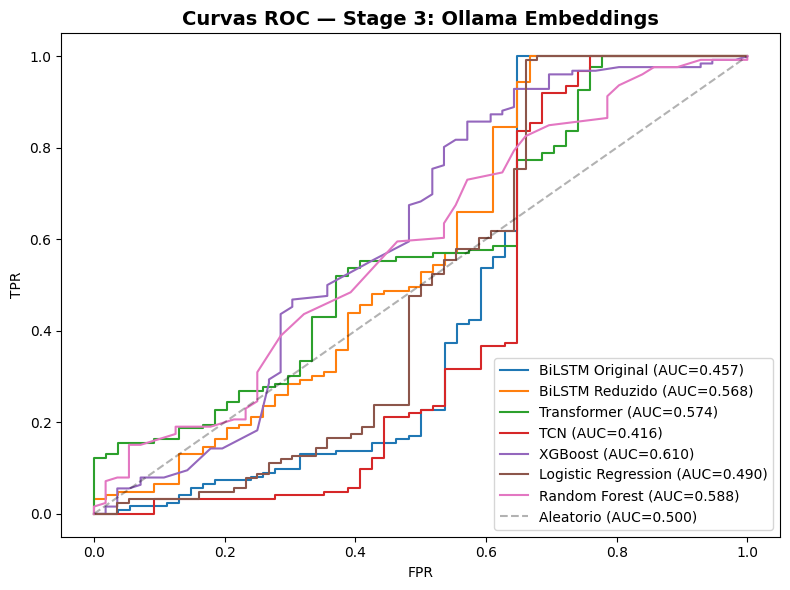

In [5]:
plot_roc_curves(results, title="Curvas ROC — Stage 3: Ollama Embeddings",
                save_path="results/stage3_roc.png")

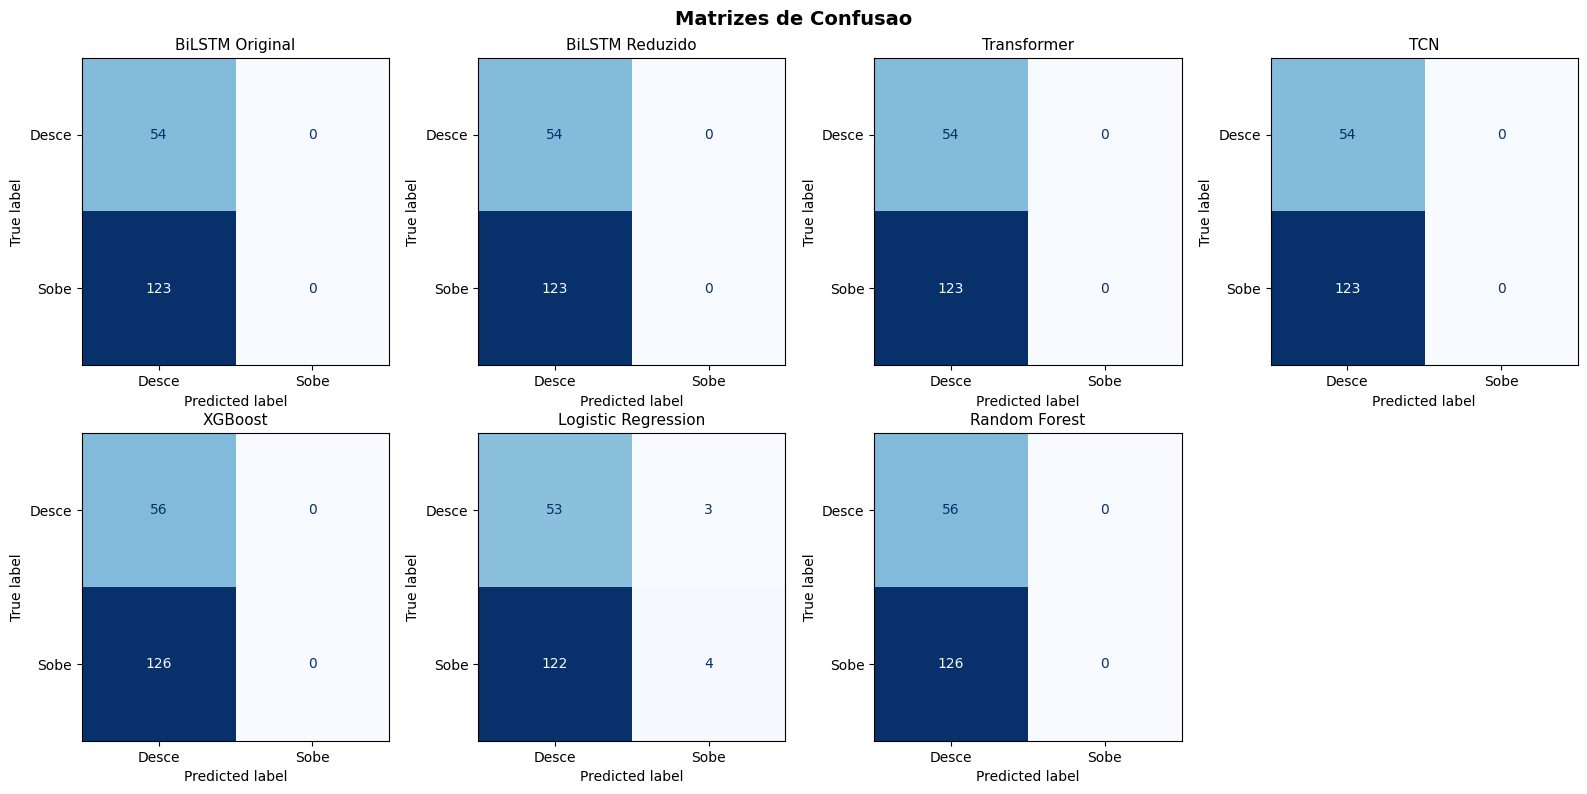

In [6]:
plot_confusion_matrices(
    {name: r["classification"] for name, r in results.items()},
    save_path="results/stage3_confusion.png",
)

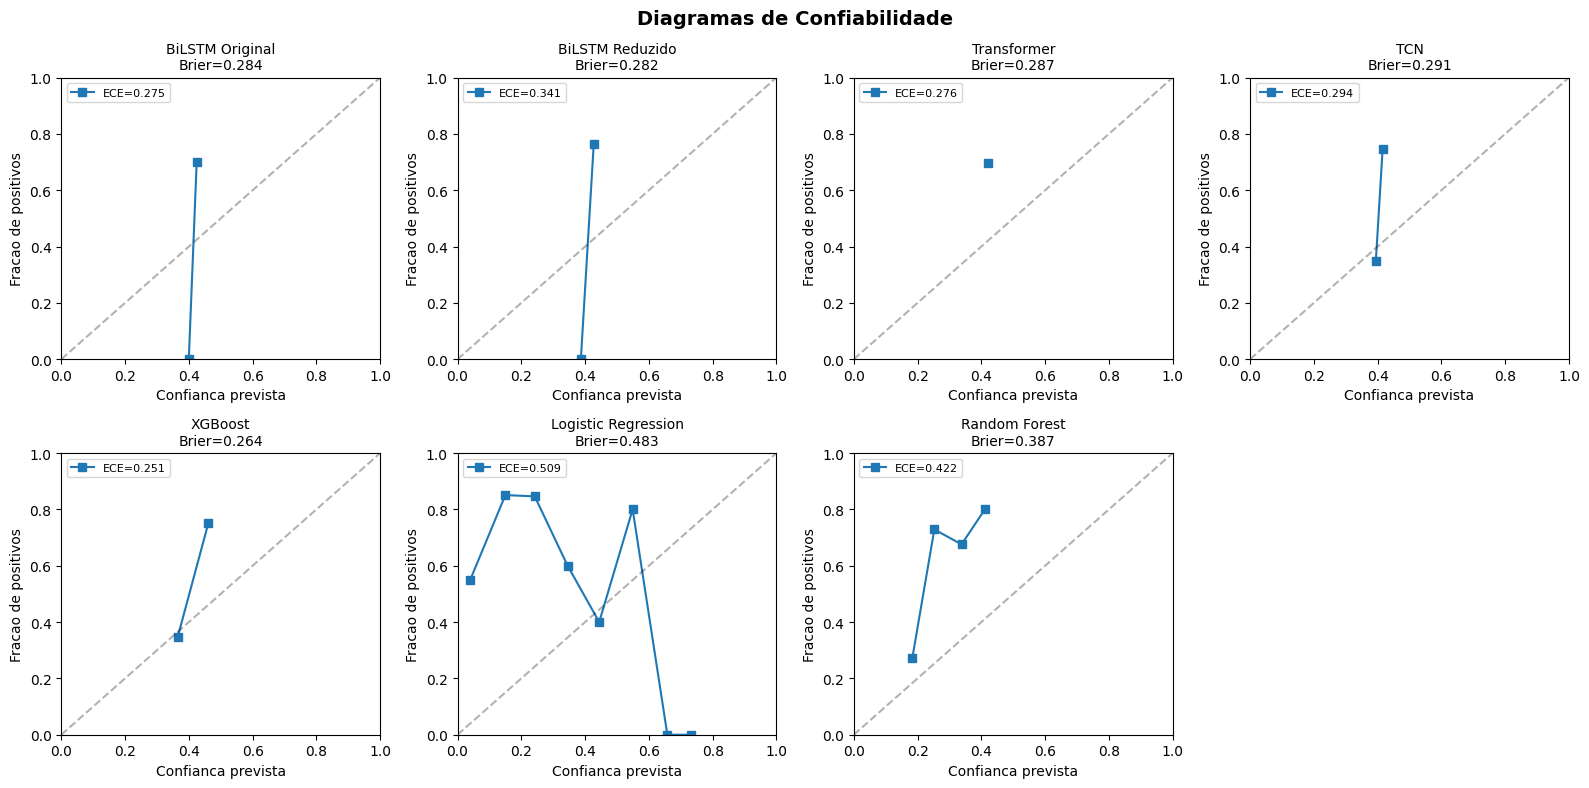

In [7]:
plot_calibration_diagrams(
    {name: r["calibration"] for name, r in results.items()},
    save_path="results/stage3_calibration.png",
)

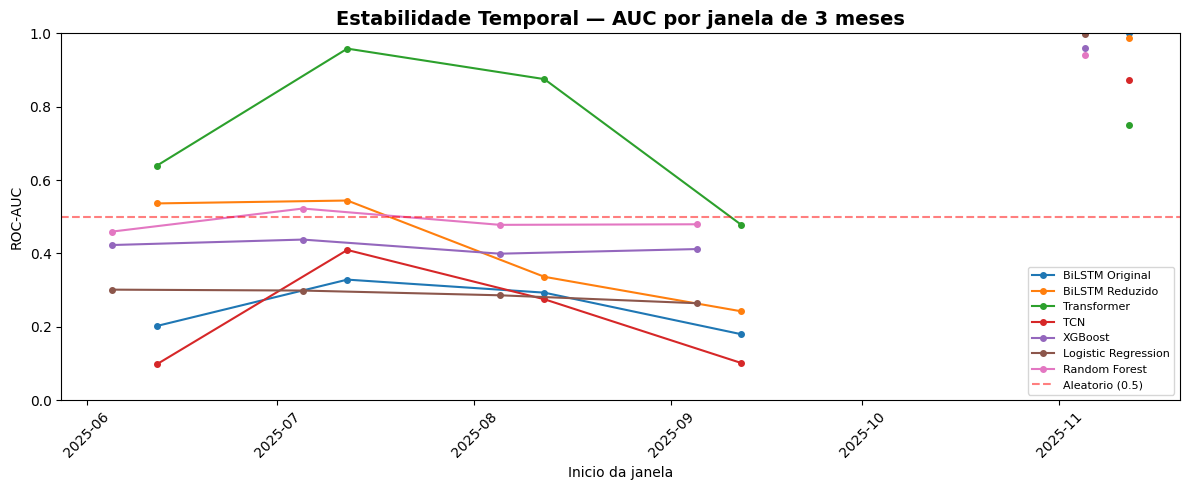

In [8]:
plot_temporal_stability(
    {name: r["temporal_stability"] for name, r in results.items()},
    save_path="results/stage3_temporal.png",
)

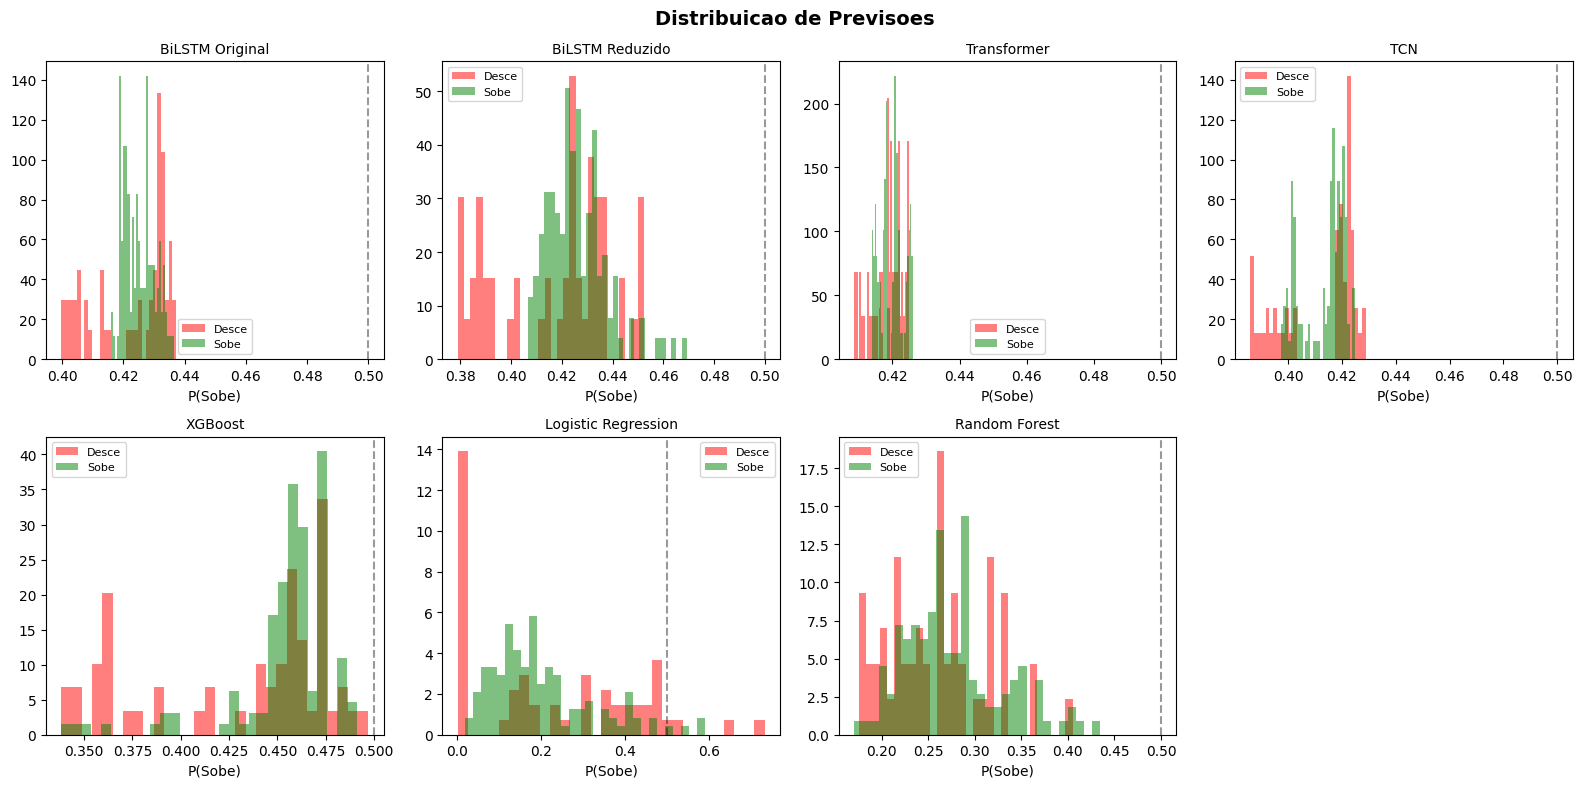

In [9]:
plot_prediction_distributions(
    {name: r["prediction_distribution"] for name, r in results.items()},
    save_path="results/stage3_distributions.png",
)

## Interpretabilidade (SHAP + Permutation Importance)

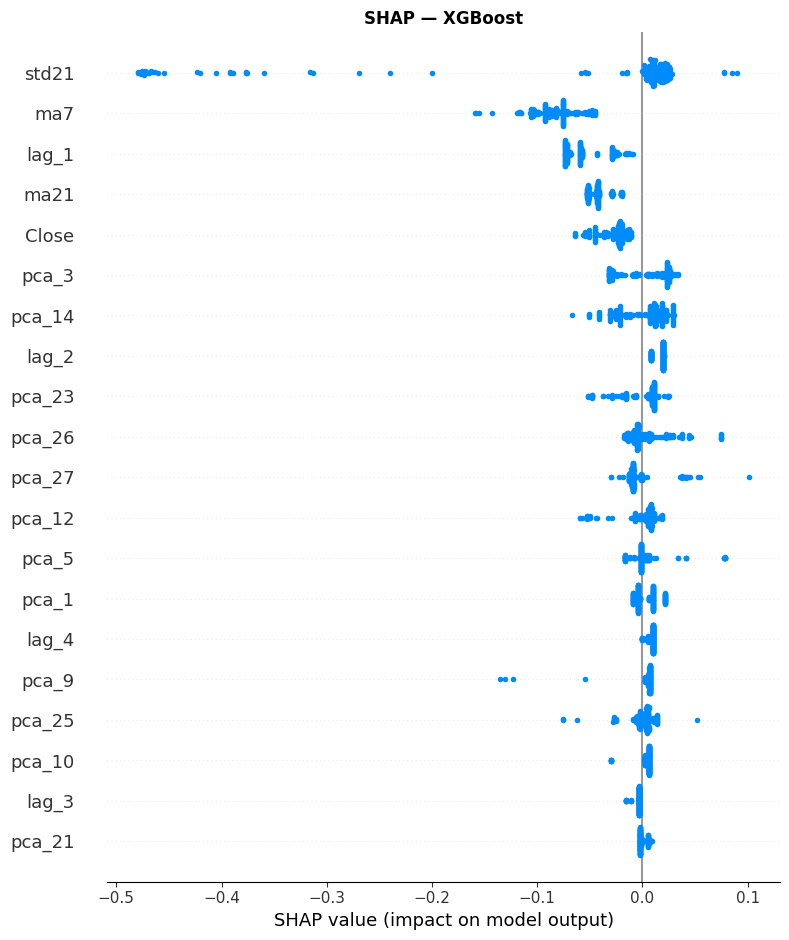

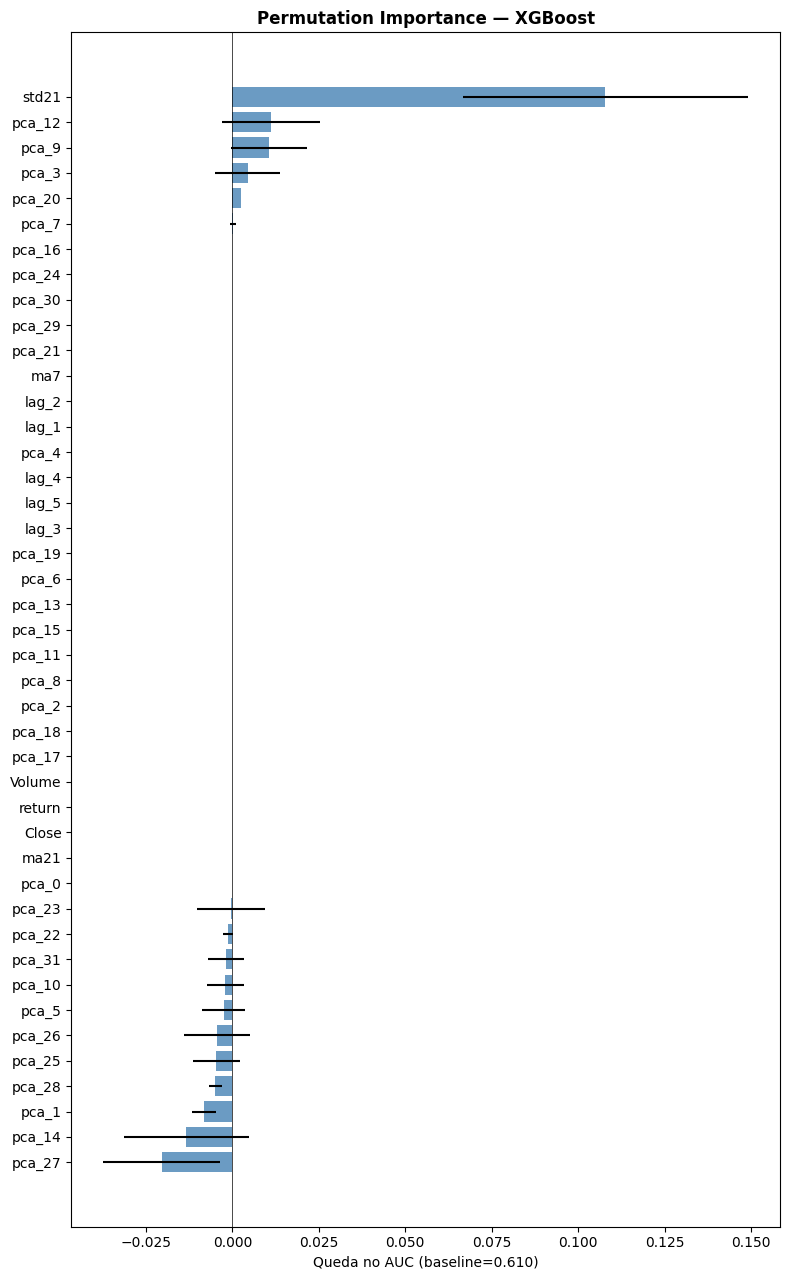

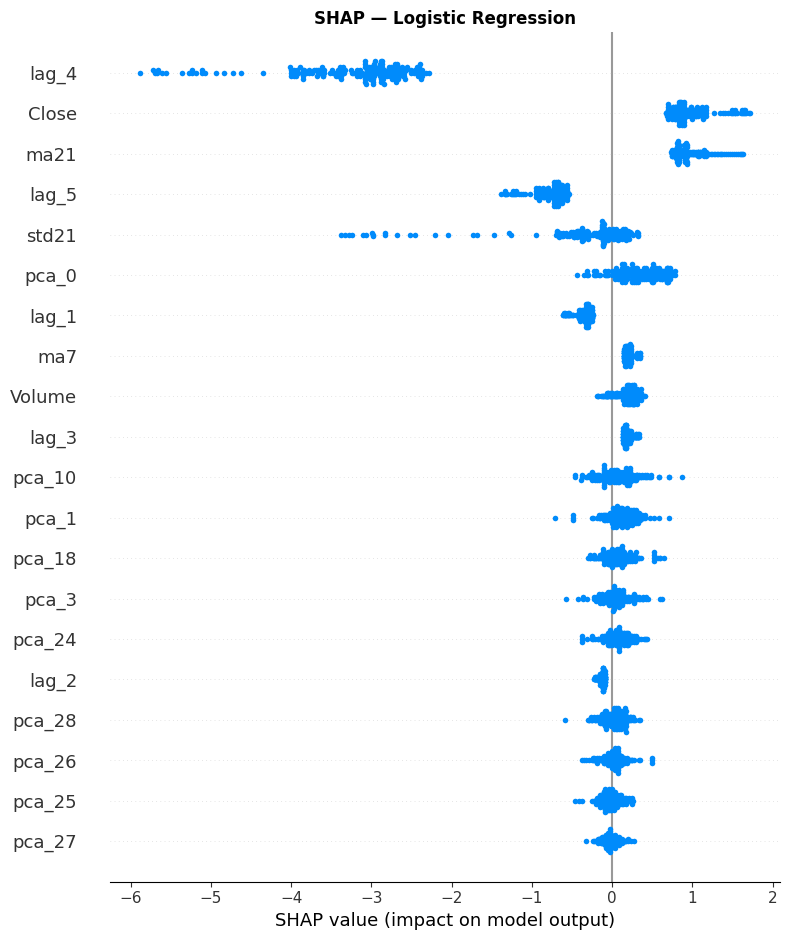

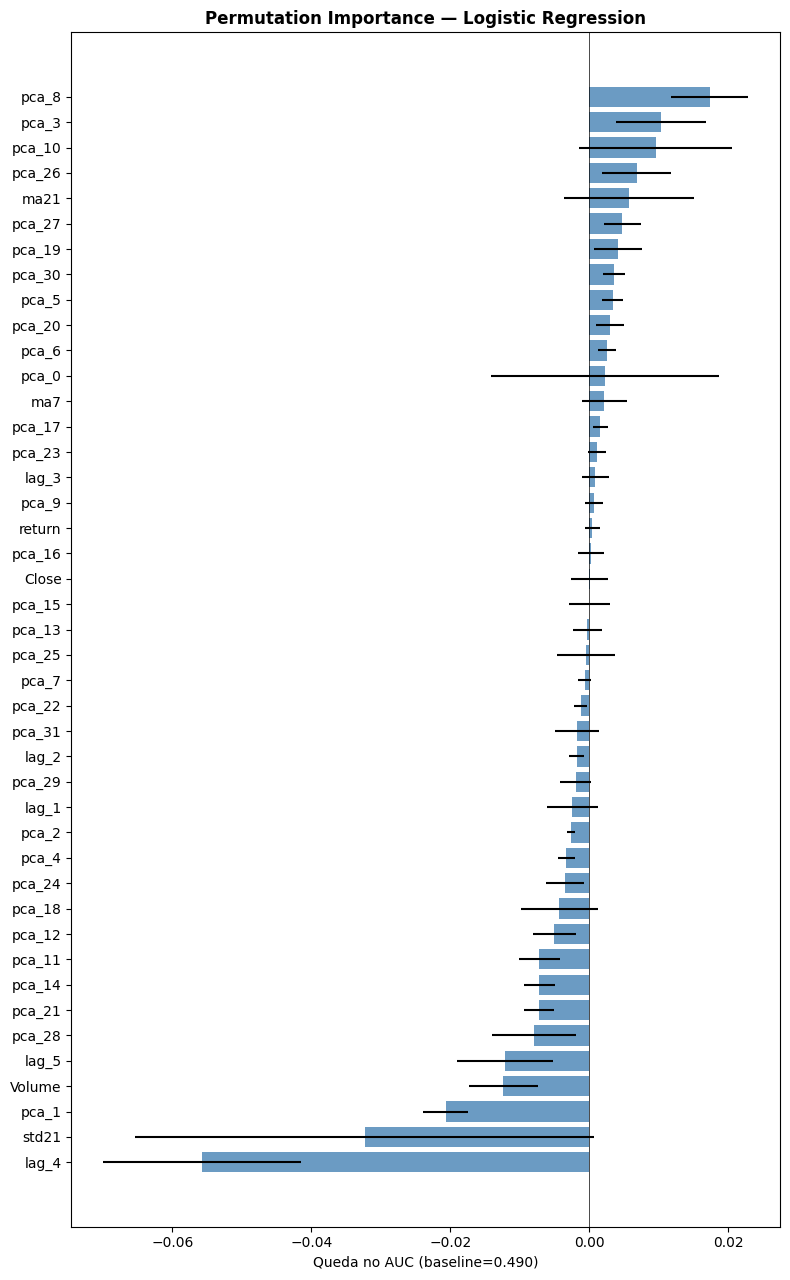

<Figure size 1000x1290 with 0 Axes>

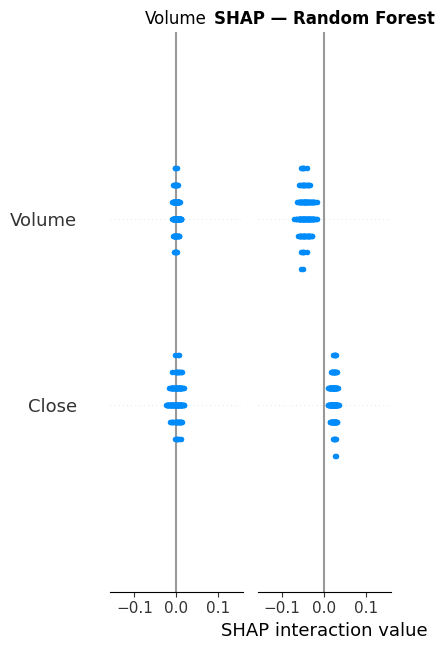

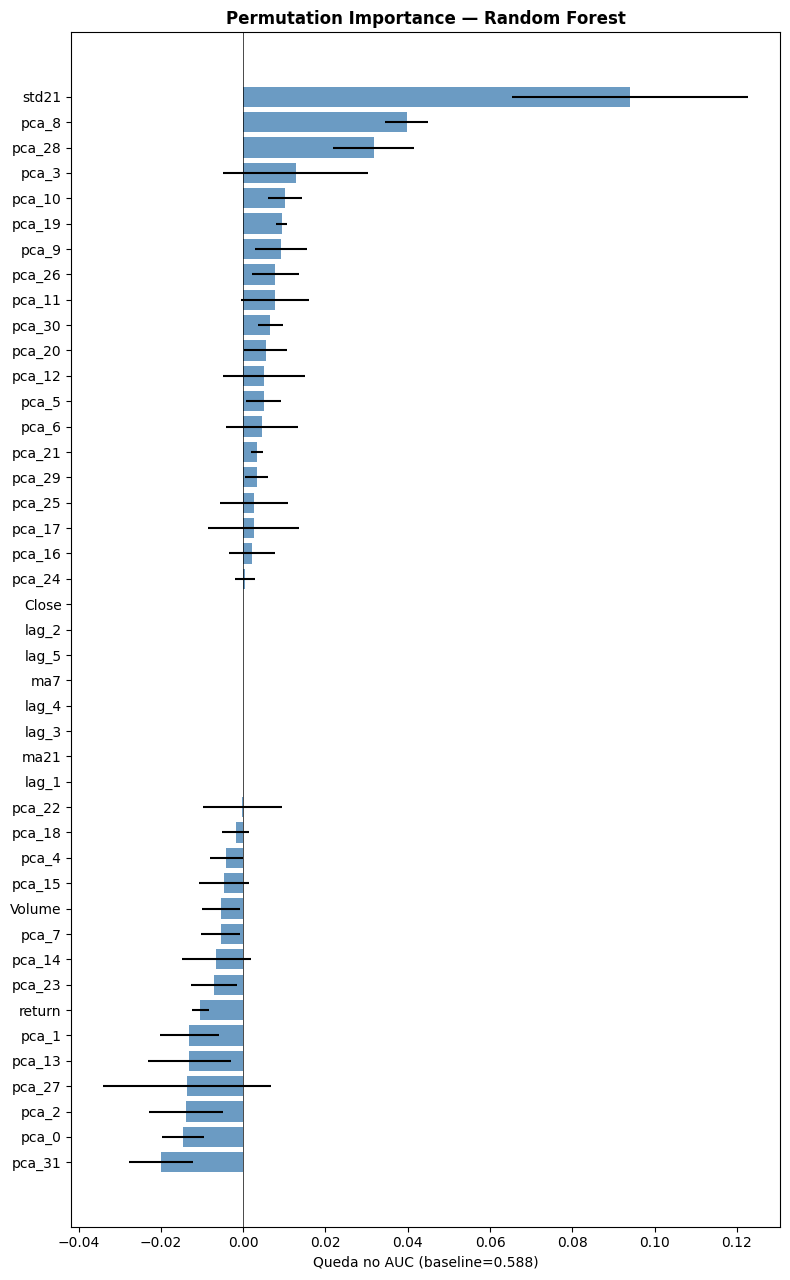

In [10]:
for name in ["XGBoost", "Logistic Regression", "Random Forest"]:
    r = results[name]
    if r["shap_values"] is not None:
        plot_shap_summary(
            r["shap_values"], data["feature_names"],
            title=f"SHAP — {name}",
            save_path=f"results/stage3_shap_{name.lower().replace(' ','_')}.png",
        )
    if r["permutation_importance"] is not None:
        plot_feature_importance(
            r["permutation_importance"],
            r["classification"]["roc_auc"],
            title=f"Permutation Importance — {name}",
            save_path=f"results/stage3_perm_{name.lower().replace(' ','_')}.png",
        )

## Curvas de aprendizado

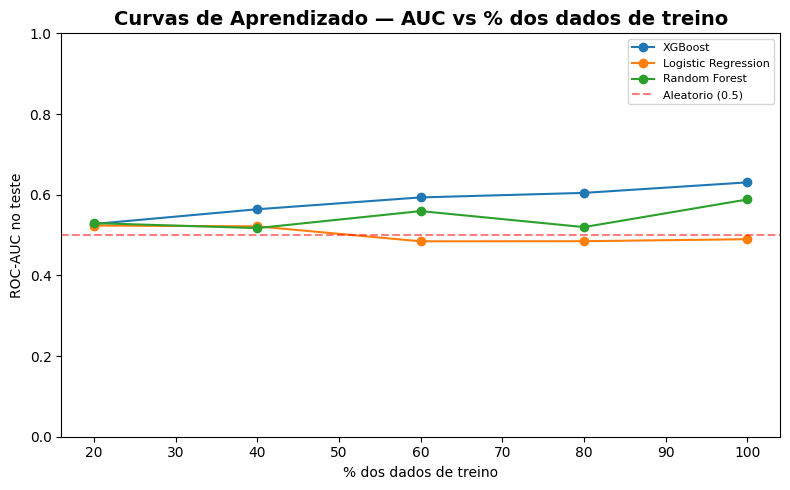

In [11]:
lc_results = {name: r["learning_curve"] for name, r in results.items()
               if r["learning_curve"] is not None}
if lc_results:
    plot_learning_curves(lc_results, save_path="results/stage3_learning_curves.png")

## Variacoes de hiperparametros

In [12]:
VARIATIONS = {
    "Transformer d=32": {"model_name": "transformer", "model_params": {"d_model": 32, "nhead": 2}},
    "Transformer d=128": {"model_name": "transformer", "model_params": {"d_model": 128, "nhead": 8}},
    "Transformer 4L": {"model_name": "transformer", "model_params": {"n_layers": 4}},
    "XGBoost depth=3": {"model_name": "xgboost", "model_params": {"max_depth": 3}},
    "XGBoost depth=6": {"model_name": "xgboost", "model_params": {"max_depth": 6}},
    "XGBoost 500 trees": {"model_name": "xgboost", "model_params": {"n_estimators": 500}},
    "BiLSTM drop=0.1": {"model_name": "bilstm_original", "model_params": {"dropout": 0.1}},
    "BiLSTM drop=0.5": {"model_name": "bilstm_original", "model_params": {"dropout": 0.5}},
    "BiLSTM h=256": {"model_name": "bilstm_original", "model_params": {"hidden_size": 256}},
    "TCN k=2": {"model_name": "tcn", "model_params": {"kernel_size": 2}},
    "TCN k=5": {"model_name": "tcn", "model_params": {"kernel_size": 5}},
    "TCN [32,32]": {"model_name": "tcn", "model_params": {"num_channels": [32, 32]}},
    "LR C=0.01": {"model_name": "logistic_regression", "model_params": {"C": 0.01}},
    "LR C=100": {"model_name": "logistic_regression", "model_params": {"C": 100}},
    "LR L1": {"model_name": "logistic_regression", "model_params": {"penalty": "l1", "solver": "saga"}},
    "RF depth=5": {"model_name": "random_forest", "model_params": {"max_depth": 5}},
    "RF depth=20": {"model_name": "random_forest", "model_params": {"max_depth": 20}},
    "RF 500 trees": {"model_name": "random_forest", "model_params": {"n_estimators": 500}},
}

var_results = {}
for display_name, config in VARIATIONS.items():
    print(f"Variacao: {display_name}")
    var_results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        model_params=config.get("model_params", {}),
        compute_shap=False,
        compute_learning_curve=False,
    )

18:46:49 [INFO] 
18:46:49 [INFO] Modelo: transformer
18:46:49 [INFO] Split — treino: 823 | val: 176 | teste: 177
18:46:49 [INFO] ============================================================
18:46:49 [INFO] Class weights: sobe=0.801, desce=1.249 (balance: 55.5% sobe)


Variacao: Transformer d=32


/home/takeo/pessoais/tcc-takeo/7.model-evaluation/shared/trainer.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample_weights = torch.tensor(sample_weights, dtype=torch.float32).to(device)
18:46:50 [INFO] Epoch   1/50 | loss 0.6983 | val_loss 0.6808 | val_acc 40.9% | lr 1.00e-03
18:46:50 [INFO] Epoch   2/50 | loss 0.6857 | val_loss 0.6794 | val_acc 38.6% | lr 1.00e-03
18:46:50 [INFO] Epoch   3/50 | loss 0.6722 | val_loss 0.6802 | val_acc 38.6% | lr 1.00e-03
18:46:50 [INFO] Epoch   4/50 | loss 0.6459 | val_loss 0.6857 | val_acc 40.3% | lr 1.00e-03
18:46:50 [INFO] Epoch   5/50 | loss 0.6151 | val_loss 0.7576 | val_acc 40.9% | lr 1.00e-03
18:46:50 [INFO] Epoch   6/50 | loss 0.5650 | val_loss 0.8381 | val_acc 42.0% | lr 1.00e-03
18:46:51 [INFO] Epoch   7/50 | loss 0.5529 | val_loss 0.8927 | val_acc 43.8% | lr 1.00e-03
18:46:51 [INFO

Variacao: Transformer d=128


/home/takeo/pessoais/tcc-takeo/7.model-evaluation/shared/trainer.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample_weights = torch.tensor(sample_weights, dtype=torch.float32).to(device)
18:46:52 [INFO] Epoch   1/50 | loss 0.7397 | val_loss 0.6858 | val_acc 61.4% | lr 1.00e-03
18:46:52 [INFO] Epoch   2/50 | loss 0.7019 | val_loss 0.6796 | val_acc 38.6% | lr 1.00e-03
18:46:52 [INFO] Epoch   3/50 | loss 0.6909 | val_loss 0.6796 | val_acc 38.6% | lr 1.00e-03
18:46:52 [INFO] Epoch   4/50 | loss 0.6906 | val_loss 0.6796 | val_acc 38.6% | lr 1.00e-03
18:46:52 [INFO] Epoch   5/50 | loss 0.6905 | val_loss 0.6797 | val_acc 38.6% | lr 1.00e-03
18:46:53 [INFO] Epoch   6/50 | loss 0.6904 | val_loss 0.6797 | val_acc 38.6% | lr 1.00e-03
18:46:53 [INFO] Epoch   7/50 | loss 0.6903 | val_loss 0.6797 | val_acc 38.6% | lr 1.00e-03
18:46:53 [INFO

...

/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
1

Variacao: RF depth=20


/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
1

Variacao: RF 500 trees


/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
1

In [13]:
var_rows = []
for name, r in var_results.items():
    var_rows.append({
        "Variacao": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1": f"{r['classification']['f1']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
    })

df_var = pd.DataFrame(var_rows)
print("\n" + "="*60)
print("VARIACOES DE HIPERPARAMETROS")
print("="*60)
display(df_var)


VARIACOES DE HIPERPARAMETROS


,Variacao,ROC-AUC,Accuracy,F1,ECE
0,Transformer d=32,0.5269,30.5%,0.0000,0.2447
1,Transformer d=128,0.5181,30.5%,0.0000,0.2219
2,Transformer 4L,0.6885,30.5%,0.0000,0.2919
3,XGBoost depth=3,0.6220,45.1%,0.4253,0.2045
4,XGBoost depth=6,0.6282,30.2%,0.0000,0.2259
5,XGBoost 500 trees,0.6103,30.8%,0.0000,0.2505
6,BiLSTM drop=0.1,0.4283,30.5%,0.0000,0.2637
7,BiLSTM drop=0.5,0.4225,30.5%,0.0000,0.2456
8,BiLSTM h=256,0.4259,30.5%,0.0000,0.3031
9,TCN k=2,0.4428,30.5%,0.0000,0.3901


## Salvar resultados

In [14]:
all_results = {**results, **var_results}
save_results_json(all_results, "results/stage3_metrics.json")
print("Resultados salvos em results/stage3_metrics.json")

18:47:49 [INFO] Resultados salvos em results/stage3_metrics.json


Resultados salvos em results/stage3_metrics.json
